# 04 - Frame Extraction

This notebook documents the frame extraction stage used to create the first visual sample for modeling and temporal alert evaluation.

## Why This Notebook Exists

The extraction itself is performed by scripts for reproducibility, but this notebook summarizes the generated artifacts and provides a convenient place to inspect extracted frames.

## Commands Used

```powershell
.\venv\Scripts\python.exe scripts\create_sample.py
.\venv\Scripts\python.exe scripts\extract_sample_frames.py
```

Generated outputs:

- `data/interim/sample_100_videos.csv`
- `data/interim/sample_frames_manifest.csv`
- `data/interim/frames_sample/`
- `outputs/figures/positive_timeline_00364.png`
- `outputs/figures/negative_timeline_01840.png`
- `outputs/figures/positive_vs_negative_example.png`

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
FRAMES_DIR = INTERIM_DATA_DIR / "frames_sample"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

sample_csv = INTERIM_DATA_DIR / "sample_100_videos.csv"
manifest_csv = INTERIM_DATA_DIR / "sample_frames_manifest.csv"

sample_csv, manifest_csv, FRAMES_DIR

(WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction/data/interim/sample_100_videos.csv'),
 WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction/data/interim/sample_frames_manifest.csv'),
 WindowsPath('c:/Users/z004hn4c/Documents/Estudo/LLMOps And AIOps Bootcamp With 8 End To End Projects/nexar-dashcam-collision-prediction/data/interim/frames_sample'))

## Sample Summary

In [2]:
sample_df = pd.read_csv(sample_csv, dtype={"id": str})
manifest_df = pd.read_csv(manifest_csv, dtype={"id": str})

print(f"Sample videos: {len(sample_df)}")
print(f"Extracted frames: {len(manifest_df)}")
display(sample_df["target"].value_counts().sort_index().rename("videos"))
display(manifest_df.groupby(["target", "frame_label"]).size().rename("frames"))

Sample videos: 100
Extracted frames: 500


target
0    50
1    50
Name: videos, dtype: int64

target  frame_label   
0       video_20pct       50
        video_40pct       50
        video_60pct       50
        video_80pct       50
        video_95pct       50
1       alert             50
        event             50
        event_minus_1s    50
        event_minus_3s    50
        event_minus_5s    50
Name: frames, dtype: int64

## Extracted Frame Manifest

In [3]:
manifest_df.head(10)

,id,target,frame_label,timestamp,frame_path,fps,duration,frame_count
0,01840,0,video_20pct,8.180,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
1,01840,0,video_40pct,16.360,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
2,01840,0,video_60pct,24.540,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
3,01840,0,video_80pct,32.720,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
4,01840,0,video_95pct,38.855,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,40.9,1227
5,01372,0,video_20pct,3.600,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,18.0,540
6,01372,0,video_40pct,7.200,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,18.0,540
7,01372,0,video_60pct,10.800,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,18.0,540
8,01372,0,video_80pct,14.400,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,18.0,540
9,01372,0,video_95pct,17.100,C:\Users\z004hn4c\Documents\Estudo\LLMOps And ...,30.0,18.0,540


## Timeline Figures

c:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\outputs\figures\positive_timeline_00364.png


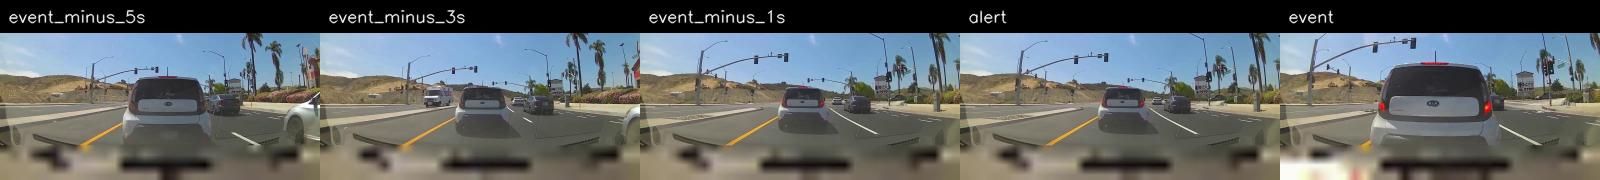

c:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\outputs\figures\negative_timeline_01840.png


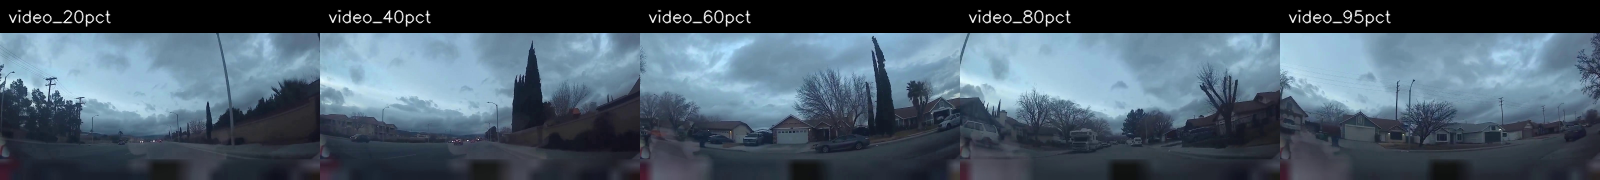

c:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\outputs\figures\positive_vs_negative_example.png


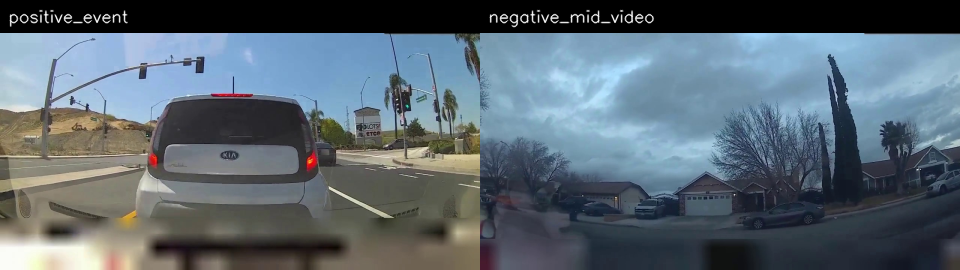

In [4]:
for figure_name in [
    "positive_timeline_00364.png",
    "negative_timeline_01840.png",
    "positive_vs_negative_example.png",
]:
    figure_path = FIGURES_DIR / figure_name
    print(figure_path)
    display(Image(filename=str(figure_path)))

## Inspect Frames From One Video

event_minus_5s 15.427 C:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\data\interim\frames_sample\00364\event_minus_5s.jpg


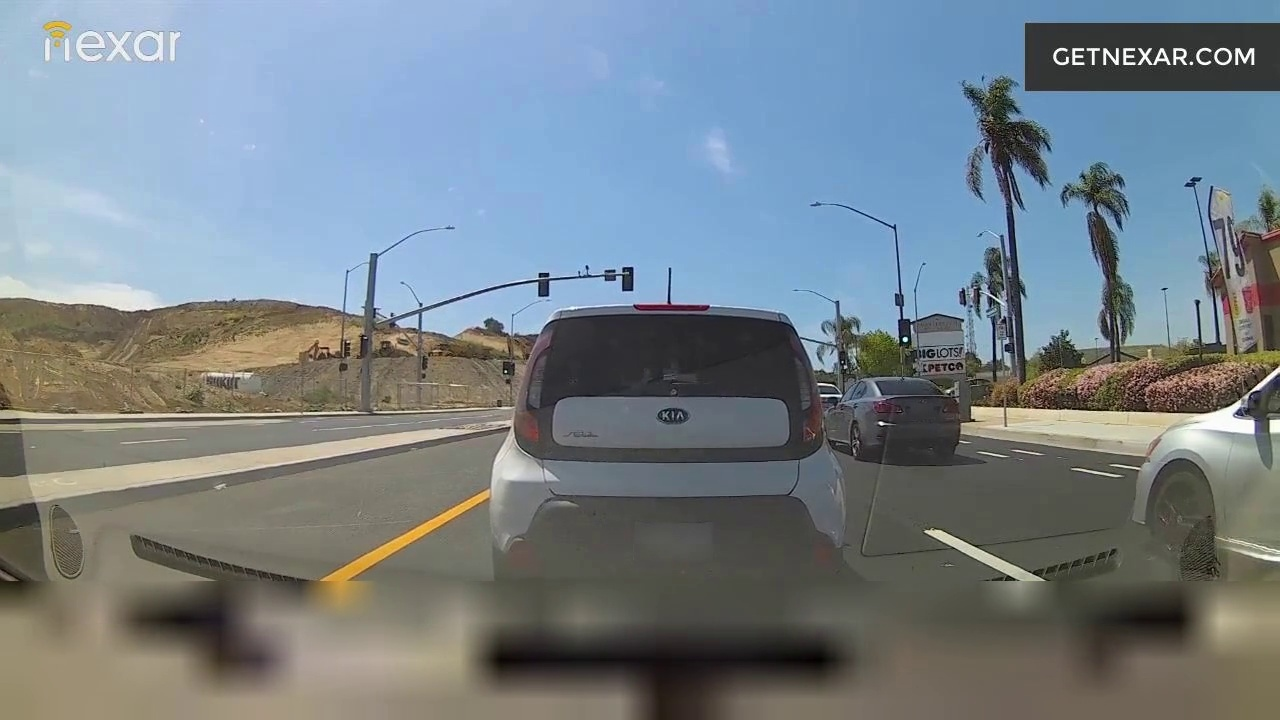

event_minus_3s 17.427 C:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\data\interim\frames_sample\00364\event_minus_3s.jpg


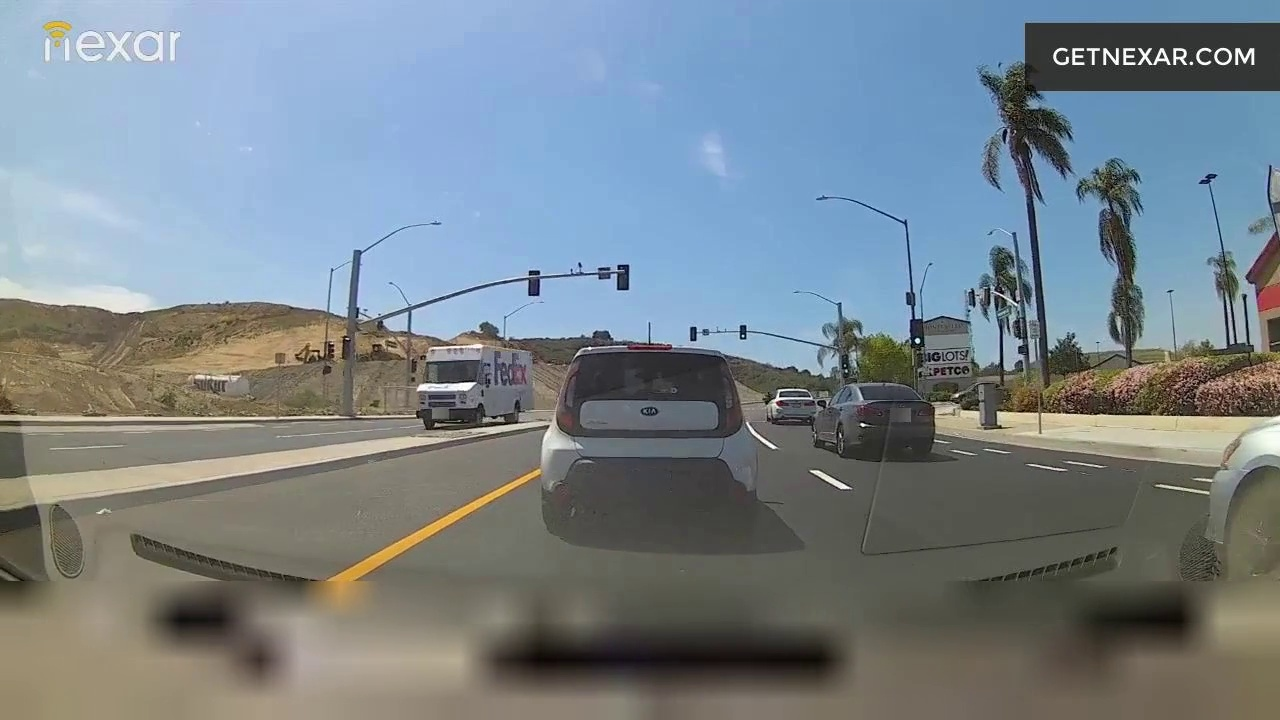

event_minus_1s 19.427 C:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\data\interim\frames_sample\00364\event_minus_1s.jpg


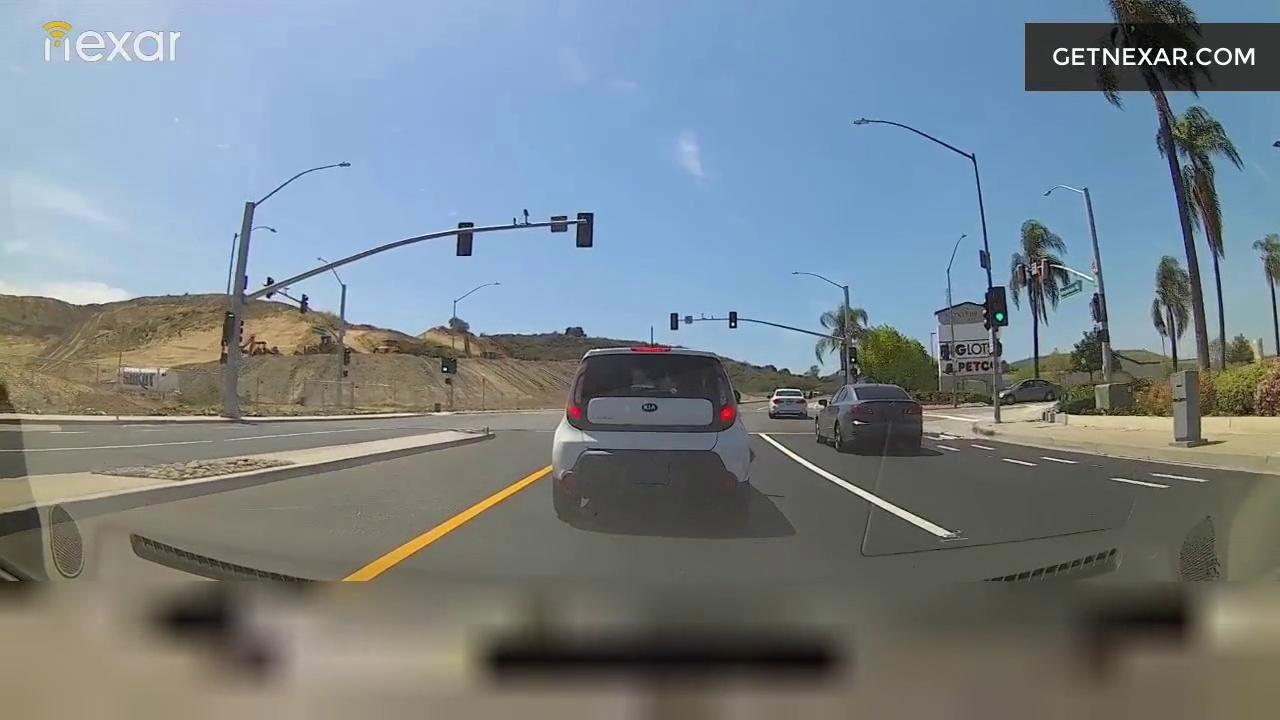

alert 19.447 C:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\data\interim\frames_sample\00364\alert.jpg


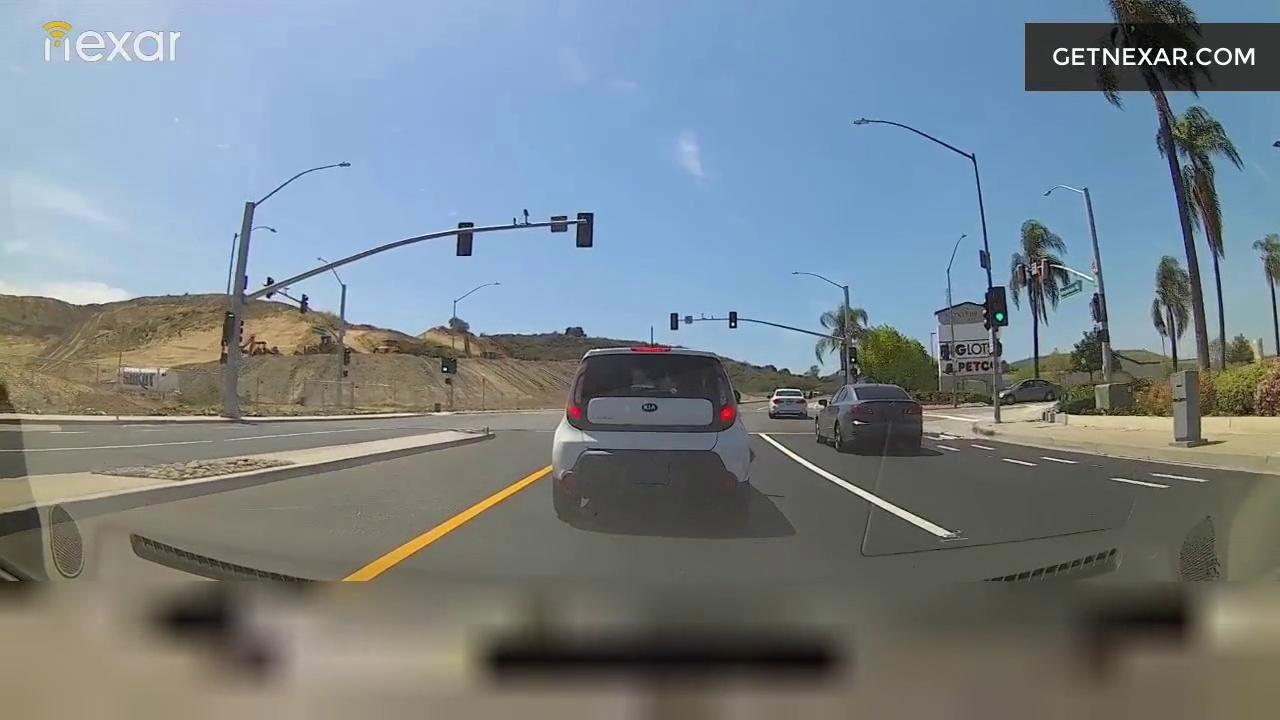

event 20.427 C:\Users\z004hn4c\Documents\Estudo\LLMOps And AIOps Bootcamp With 8 End To End Projects\nexar-dashcam-collision-prediction\data\interim\frames_sample\00364\event.jpg


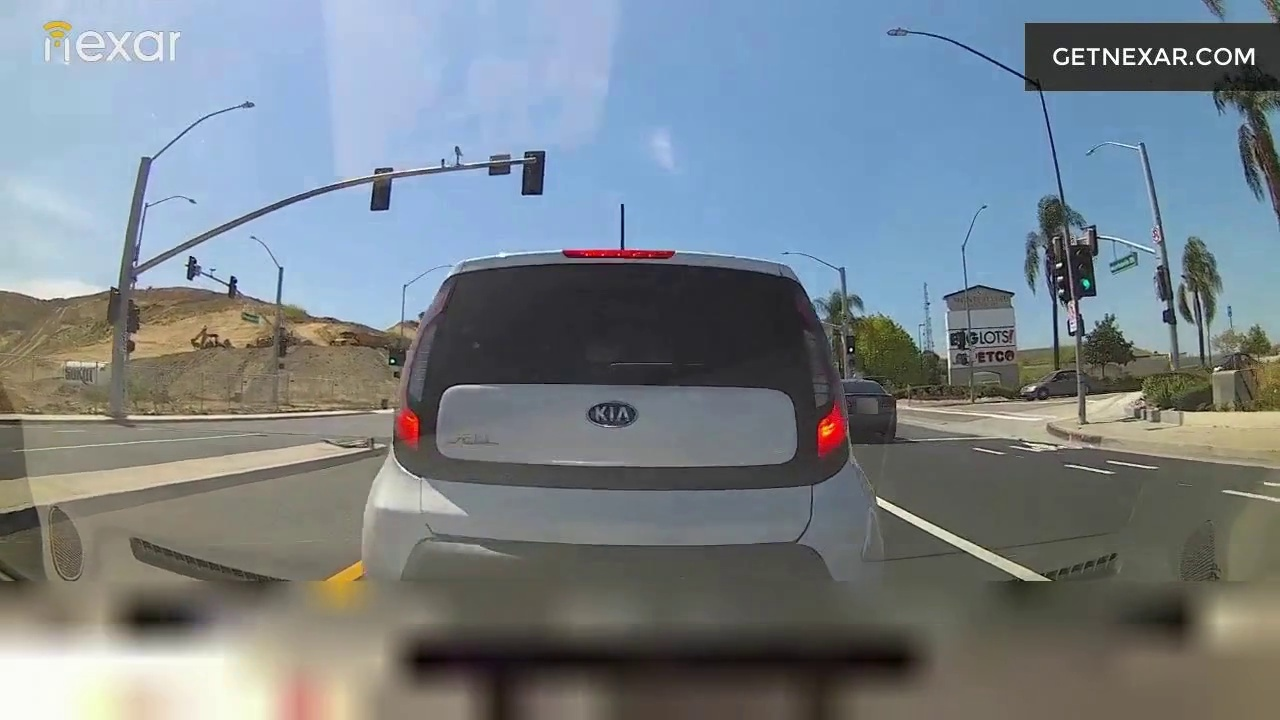

In [5]:
video_id = "00364"
video_frames = manifest_df[manifest_df["id"] == video_id].sort_values("timestamp")

for _, row in video_frames.iterrows():
    print(row["frame_label"], row["timestamp"], row["frame_path"])
    display(Image(filename=row["frame_path"], width=480))

## Notes

Positive videos are sampled around the event and alert timestamps. Negative videos are sampled at fixed percentages across the video. This gives a first controlled frame dataset for baseline modeling, but future temporal models should use denser sampling and labels based on distance to `time_of_alert` and `time_of_event`.